In [34]:
import os
import subprocess
from torchvision import io

# Identify SinGAN models capable of synthesizing high-quality images.

TRAINED_MODELS_PATH = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/TrainedModels'
RANDOM_SAMPLES_PY = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/random_samples.py'
FULL_DATASET_FOLDER_PATH = '/home/miguel/GI/0 - Data Exploration & Analysis/GI-Roberta/gi-roberta-dataset/full_dataset_rgba'
OUTPUT_FOLDER_PATH = 'Output_benchmark'
RANDOM_SAMPLES = '/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/Output_benchmark/RandomSamples'


In [35]:
image_name = 'FD-030-slice-18-image'
folder_path = os.path.join(RANDOM_SAMPLES, image_name, 'gen_start_scale=0')

In [36]:
folder_path

'/home/miguel/GI/1.5 - Synthetic Data Generation/Singan-Seg/Output_benchmark/RandomSamples/FD-030-slice-18-image/gen_start_scale=0'

In [63]:
synthetic_image_name = os.listdir(folder_path)[0]
synthetic_image_path = os.path.join(folder_path, synthetic_image_name)
original_image_path = '/home/miguel/GI/0 - Data Exploration & Analysis/GI-Roberta/gi-roberta-dataset/full_dataset_rgba/FD-030-slice-18-image.png'

In [66]:
synthetic_image = io.read_image(synthetic_image_path)
original_image = io.read_image(original_image_path)
synthetic_image = synthetic_image[:3]
original_image = original_image[:3]

In [67]:
import cv2
import numpy as np
original_image = np.transpose(original_image, (1, 2, 0))
real_gray = cv2.cvtColor(np.asarray(original_image), cv2.COLOR_RGB2GRAY)

# Resize to 256x256
synthetic_image = np.transpose(synthetic_image, (1, 2, 0))
synthetic_image = cv2.resize(np.asarray(synthetic_image), (256, 256), interpolation=cv2.INTER_LINEAR)
synthetic_gray = cv2.cvtColor(np.asarray(synthetic_image), cv2.COLOR_RGB2GRAY)

# Resize to 256x256
real_gray = cv2.resize(np.asarray(real_gray), (256, 256), interpolation=cv2.INTER_LINEAR)

In [68]:
from skimage.metrics import structural_similarity as ssim

In [69]:
ssim(real_gray, synthetic_gray)

np.float64(0.6088101197573752)

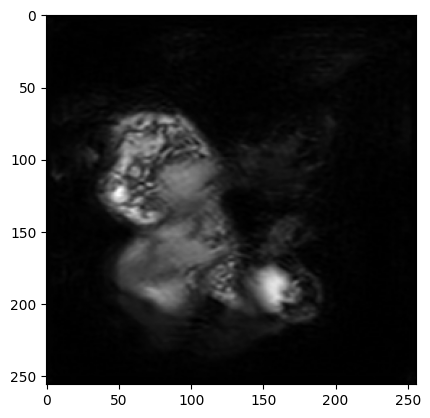

In [72]:
import matplotlib.pyplot as plt
plt.imshow(synthetic_gray, cmap='gray')

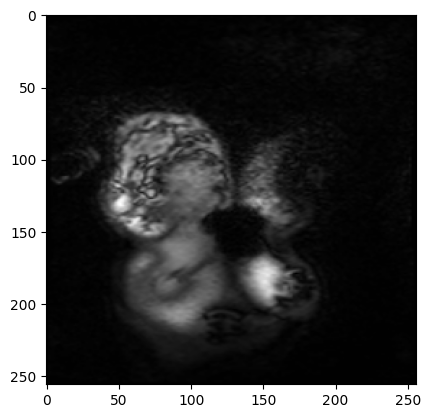

In [73]:

plt.imshow(original_image)

In [75]:
synthetic_gray.flatten().mean()

np.float64(19.20855712890625)

In [80]:
np.asarray(original_image).flatten().mean()

np.float64(23.033737182617188)